# Snapshot bin-centered vs raw PySR sandbox

Compare PySR on the snapshot dataset with and without per-timepoint mean subtraction. Centering uses training-only means (no test leakage), then we contrast metrics and per-bin plots.


## How to use

- Set `MARKER`, `TEST_SIZE`, and tweak `PYSR_KWARGS` below.
- Snapshot data defaults to `data/experimental/processed/functional_groups/functional_groups_fit_snapshot.csv`.
- Bin split is applied once on cleaned rows and reused for both strategies.
- Timepoint means are computed on **train rows only**; test centering/reconstruction reuses those means.
- Boxplots compare per-bin R2 on the raw target for centered vs raw fits across train/test.


In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")
PROJECT_ROOT = Path.cwd().resolve()
PROJECT_ROOT


PosixPath('/Users/pomeret/Desktop/symbolic_regression_signalling/notebooks')

In [2]:
SNAPSHOT_PATH = "../data/experimental/processed/functional_groups/functional_groups_fit_snapshot.csv"
MARKER = "DUSP4"
TEST_SIZE = 0.25
RANDOM_STATE = 7

# Keep this modest for a sandbox; bump iterations/populations for a stronger search.
PYSR_KWARGS = {
    "niterations": 400,
    "population_size": 30,
    "populations": 30,
    "maxsize": 20,
    "parsimony": 0.8,
    "binary_operators": ["+", "-", "*", "/"],
    "unary_operators": [],
    "batching": True,
    "annealing": True,
    "verbosity": 0,
}

print(f"Using marker={MARKER}, test_size={TEST_SIZE}, random_state={RANDOM_STATE}")
SNAPSHOT_PATH


Using marker=DUSP4, test_size=0.25, random_state=7


'../data/experimental/processed/functional_groups/functional_groups_fit_snapshot.csv'

In [3]:
import sys

# make project root importable
sys.path.append('../')

# try to import utilities from the project, give a clearer error if unavailable
try:
    from src.experimental.sr_pipeline.run_functional_groups import (
        choose_bin_split,
        sanitize_feature_names,
        EXCLUDE_COLUMNS,
    )
except Exception as exc:
    raise ImportError(
        "Failed to import utilities from src.experimental.sr_pipeline.run_functional_groups. "
        "Ensure PROJECT_ROOT is correct and the package is available on sys.path."
    ) from exc


def compute_metrics(y_true_train, y_pred_train, y_true_test, y_pred_test):
    def rel_mae(y_true, y_pred):
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        if not np.any(mask):
            return np.nan
        denom = np.maximum(np.abs(y_true[mask]), 1e-2)
        return float(np.mean(np.abs(y_pred[mask] - y_true[mask]) / denom))

    def r2(y_true, y_pred):
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        if np.sum(mask) < 2:
            return np.nan
        yt = y_true[mask]
        yp = y_pred[mask]
        if len(np.unique(yp)) <= 1:
            return np.nan
        return float(np.corrcoef(yt, yp)[0, 1] ** 2)

    return {
        "train_r2": r2(y_true_train, y_pred_train),
        "test_r2": r2(y_true_test, y_pred_test),
        "train_rel_mae": rel_mae(y_true_train, y_pred_train),
        "test_rel_mae": rel_mae(y_true_test, y_pred_test),
    }


def center_with_train_means(train_df, test_df, target_col="p-ERK1-2_dt"):
    """Center targets using training-only timepoint means (no leakage).

    Returns updated (train_df, test_df, time_means_train).
    """
    # compute train-only timepoint means; keep the series name for downstream display
    train_means = train_df.groupby("timepoint")[target_col].mean()
    train_means.name = target_col
    fallback = float(train_df[target_col].mean()) if not train_df.empty else 0.0

    def _apply(frame):
        out = frame.copy()
        out["timepoint_mean_train"] = out["timepoint"].map(train_means).fillna(fallback)
        out["target_centered"] = out[target_col] - out["timepoint_mean_train"]
        return out

    return _apply(train_df), _apply(test_df), train_means


def prepare_features(df, feature_cols, sanitized_names):
    X = df[feature_cols].copy()
    if len(sanitized_names) != len(X.columns):
        raise ValueError("Length of sanitized_names must match number of feature columns.")
    X.columns = sanitized_names
    return X


In [4]:
raw = pd.read_csv(SNAPSHOT_PATH)
raw.columns = raw.columns.str.replace("_fit$", "", regex=True)
raw["p-ERK1-2_dt"] = pd.to_numeric(raw.get("p-ERK1-2_dt"), errors="coerce")
raw["GFP_bin"] = pd.to_numeric(raw.get("GFP_bin"), errors="coerce")
raw["timepoint"] = pd.to_numeric(raw.get("timepoint"), errors="coerce")

marker_df = raw[raw["marker"] == MARKER].copy()
marker_df = marker_df.dropna(subset=["p-ERK1-2_dt", "GFP_bin", "timepoint"])
print(f"Rows for marker (after target/bin/time drop): {len(marker_df)}")
print(f"Available bins: {sorted(marker_df['GFP_bin'].unique())}")
marker_df.head()


Rows for marker (after target/bin/time drop): 282
Available bins: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46)]


,marker,GFP_bin,timepoint,GFP,p-ERK1-2,p-ERK1-2_dt,p-ERK1-2_min,p-MEK1-2,p-MEK1-2_dt,p-MEK1-2_min,p-RAF,p-p90RSK,p-MAPKAPK2,p-PDK1,p-MKK3-6
1752,DUSP4,0,0.0,0.000715,1.159707,0.301551,1.148149,1.270242,0.587957,1.247412,0.701846,0.676775,2.864621,2.194589,1.189550
1753,DUSP4,0,5.0,0.000557,4.118371,0.478999,1.148149,3.136287,0.040009,1.247412,0.704714,2.652340,3.103765,2.393489,1.322830
1754,DUSP4,0,10.0,0.000725,3.585577,-0.242987,1.148149,2.516866,-0.145671,1.247412,0.774154,2.502629,3.194064,2.536510,1.427287
1755,DUSP4,0,15.0,0.000628,3.005036,-0.043396,1.148149,2.118441,-0.038706,1.247412,0.742258,1.801665,3.076874,2.309143,1.197198
1756,DUSP4,0,30.0,0.000721,2.664427,-0.019669,1.148149,1.727012,-0.024239,1.247412,0.701931,1.505759,2.949717,2.141986,1.005158


In [5]:
feature_cols = [c for c in marker_df.columns if c not in EXCLUDE_COLUMNS]
rows_before_features = len(marker_df)
marker_df = marker_df.dropna(subset=feature_cols).copy()
print(f"Rows after dropping NaN features: {len(marker_df)} (was {rows_before_features})")

train_bins, test_bins = choose_bin_split(marker_df, test_size=TEST_SIZE, random_state=RANDOM_STATE)
if not train_bins or not test_bins:
    print("Not enough bins for bin-level split; using row-level split instead.")
    rng = np.random.default_rng(RANDOM_STATE)
    idx = np.arange(len(marker_df))
    rng.shuffle(idx)
    split = max(1, int(len(idx) * (1 - TEST_SIZE)))
    train_idx = idx[:split]
    test_idx = idx[split:]
    marker_df["phase"] = "train"
    marker_df.loc[test_idx, "phase"] = "test"
else:
    marker_df["phase"] = np.where(marker_df["GFP_bin"].isin(train_bins), "train", "test")

train_df = marker_df[marker_df["phase"] == "train"].copy()
test_df = marker_df[marker_df["phase"] == "test"].copy()
print(f"Train rows: {len(train_df)}, Test rows: {len(test_df)}")
print(f"Train bins: {sorted(train_df['GFP_bin'].unique())}")
print(f"Test bins: {sorted(test_df['GFP_bin'].unique())}")


Rows after dropping NaN features: 235 (was 282)
Train rows: 175, Test rows: 60
Train bins: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(21), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(44), np.int64(45), np.int64(46)]
Test bins: [np.int64(0), np.int64(4), np.int64(6), np.int64(10), np.int64(12), np.int64(19), np.int64(20), np.int64(22), np.int64(28), np.int64(36), np.int64(37), np.int64(43)]


In [6]:
train_df, test_df, time_means_train = center_with_train_means(train_df, test_df, target_col="p-ERK1-2_dt")
time_mean_table = (
    time_means_train.reset_index()
    .rename(columns={"p-ERK1-2_dt": "mean_pERK_dt_train"})
    .sort_values("timepoint")
)
print("Train-only timepoint means used for centering/reconstruction:")
time_mean_table

combined_df = pd.concat([train_df.assign(phase="train"), test_df.assign(phase="test")], ignore_index=True)
combined_df[["marker", "GFP_bin", "timepoint", "p-ERK1-2_dt", "target_centered", "timepoint_mean_train"]].head()


Train-only timepoint means used for centering/reconstruction:


,marker,GFP_bin,timepoint,p-ERK1-2_dt,target_centered,timepoint_mean_train
0,DUSP4,1,0.0,0.300721,0.104547,0.196175
1,DUSP4,1,5.0,0.466836,0.168984,0.297852
2,DUSP4,1,10.0,-0.236302,-0.113761,-0.122541
3,DUSP4,1,15.0,-0.044695,-0.006224,-0.038471
4,DUSP4,1,30.0,-0.020709,0.002997,-0.023705


In [7]:
# Sanity-check centering: ensure test timepoints are covered by train means
train_times = set(train_df['timepoint'].unique())
test_times = set(test_df['timepoint'].unique())
missing_in_train = sorted(t for t in test_times if t not in train_times)
print(f'Train timepoints: {sorted(train_times)}')
print(f'Test timepoints:  {sorted(test_times)}')
if missing_in_train:
    print('Test timepoints missing from train (fallback to global train mean used):', missing_in_train)
else:
    print('All test timepoints covered by train means (no fallback needed).')

fallback_mean = float(train_df['p-ERK1-2_dt'].mean()) if len(train_df) else float('nan')
print(f'Fallback mean applied when timepoint missing: {fallback_mean:.4f}')


Train timepoints: [np.float64(0.0), np.float64(5.0), np.float64(10.0), np.float64(15.0), np.float64(30.0)]
Test timepoints:  [np.float64(0.0), np.float64(5.0), np.float64(10.0), np.float64(15.0), np.float64(30.0)]
All test timepoints covered by train means (no fallback needed).
Fallback mean applied when timepoint missing: 0.0619


In [8]:
sanitized_feature_names = sanitize_feature_names(feature_cols)
X_train = prepare_features(train_df, feature_cols, sanitized_feature_names)
X_test = prepare_features(test_df, feature_cols, sanitized_feature_names)
y_train_centered = train_df["target_centered"].to_numpy()
y_test_centered = test_df["target_centered"].to_numpy()
y_train_raw = train_df["p-ERK1-2_dt"].to_numpy()
y_test_raw = test_df["p-ERK1-2_dt"].to_numpy()

print(f"X_train.shape={X_train.shape}, X_test.shape={X_test.shape}")
print(f"y_train_centered mean/std: {np.mean(y_train_centered):.4f} / {np.std(y_train_centered):.4f}")


X_train.shape=(175, 10), X_test.shape=(60, 10)
y_train_centered mean/std: 0.0000 / 0.0774


In [9]:
from pysr import PySRRegressor

sr_model_centered = PySRRegressor(**PYSR_KWARGS)
sr_model_centered.fit(X_train, y_train_centered)

train_pred_centered = sr_model_centered.predict(X_train)
test_pred_centered = sr_model_centered.predict(X_test) if len(X_test) else np.array([])
centered_metrics = compute_metrics(y_train_centered, train_pred_centered, y_test_centered, test_pred_centered)
centered_formula = sr_model_centered.sympy() if getattr(sr_model_centered, "equations_", None) is not None else None
print("PySR formula (centered target):", centered_formula)
print("Metrics (centered target):", centered_metrics)


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/opt/anaconda3/envs/pysr_env/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


PySR formula (centered target): (p_p90RSK - 0.9129789)*0.014139614/(p_MEK1_2 - 1*3.0625548)
Metrics (centered target): {'train_r2': 0.38162831329686336, 'test_r2': 0.012360135022953802, 'train_rel_mae': 0.9738263422574002, 'test_rel_mae': 1.6744314205668893}


In [10]:
sr_model_raw = PySRRegressor(**PYSR_KWARGS)
sr_model_raw.fit(X_train, y_train_raw)

train_pred_raw = sr_model_raw.predict(X_train)
test_pred_raw = sr_model_raw.predict(X_test) if len(X_test) else np.array([])
raw_metrics = compute_metrics(y_train_raw, train_pred_raw, y_test_raw, test_pred_raw)
raw_formula = sr_model_raw.sympy() if getattr(sr_model_raw, "equations_", None) is not None else None
print("PySR formula (raw target):", raw_formula)
print("Metrics (raw target):", raw_metrics)


/opt/anaconda3/envs/pysr_env/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


PySR formula (raw target): (-1*(-0.31757638) + 0.20459233/(p_ERK1_2 - p_MAPKAPK2 - 0.5667785))/p_MEK1_2
Metrics (raw target): {'train_r2': 0.6259683653026715, 'test_r2': 2.3105516755313934e-05, 'train_rel_mae': 1.5422260983847906, 'test_rel_mae': 1.5374249951918826}


In [11]:
def assemble_strategy(name, frame, preds, centered=True):
    base = frame.copy().sort_values("timepoint")
    if centered:
        target_raw = base["target_centered"] + base["timepoint_mean_train"]
        pred_raw = preds + base["timepoint_mean_train"]
        target_centered = base["target_centered"]
        pred_centered = preds
    else:
        target_raw = base["p-ERK1-2_dt"]
        pred_raw = preds
        target_centered = base["p-ERK1-2_dt"] - base["timepoint_mean_train"]
        pred_centered = pred_raw - base["timepoint_mean_train"]
    out = pd.DataFrame({
        "strategy": name,
        "phase": base["phase"],
        "timepoint": base["timepoint"],
        "GFP_bin": base["GFP_bin"],
        "target_centered": target_centered,
        "pred_centered": pred_centered,
        "target_raw": target_raw,
        "pred_raw": pred_raw,
    })
    out["abs_error_raw"] = np.abs(out["pred_raw"] - out["target_raw"])
    return out

rows = []
if len(train_df):
    rows.append(assemble_strategy("centered", train_df, train_pred_centered, centered=True))
    rows.append(assemble_strategy("raw", train_df, train_pred_raw, centered=False))
if len(test_df):
    rows.append(assemble_strategy("centered", test_df, test_pred_centered, centered=True))
    rows.append(assemble_strategy("raw", test_df, test_pred_raw, centered=False))

pred_compare = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
pred_compare = pred_compare.sort_values(["GFP_bin", "phase", "timepoint"])

plot_df_centered = pred_compare[pred_compare["strategy"] == "centered"]
pred_compare.head()


,strategy,phase,timepoint,GFP_bin,target_centered,pred_centered,target_raw,pred_raw,abs_error_raw
350,centered,test,0.0,0,0.105377,0.001863,0.301551,0.198038,0.103513
410,raw,test,0.0,0,0.105377,-0.017063,0.301551,0.179111,0.122440
364,centered,test,5.0,0,0.181147,-0.008582,0.478999,0.289270,0.189729
424,raw,test,5.0,0,0.181147,-0.253761,0.478999,0.044091,0.434908
384,centered,test,10.0,0,-0.120446,-0.002409,-0.242987,-0.124950,0.118037


In [12]:
metrics_table = pd.DataFrame([
    {"strategy": "centered", **centered_metrics},
    {"strategy": "raw", **raw_metrics},
])
metrics_table


,strategy,train_r2,test_r2,train_rel_mae,test_rel_mae
0,centered,0.381628,0.012360,0.973826,1.674431
1,raw,0.625968,0.000023,1.542226,1.537425


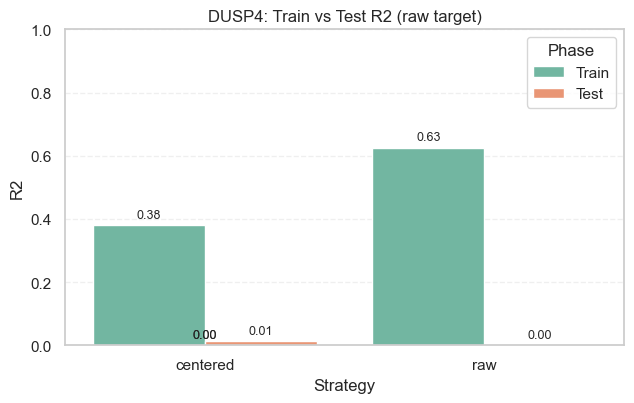

In [13]:
# Barplot of train/test R2 for raw vs centered strategies
try:
    mt = metrics_table.copy()
except NameError:
    mt = pd.DataFrame([
        {"strategy": "centered", **centered_metrics},
        {"strategy": "raw", **raw_metrics},
    ])

# reshape for plotting
plot_mt = mt.melt(id_vars="strategy", value_vars=["train_r2", "test_r2"],
                  var_name="phase", value_name="r2")
plot_mt["phase"] = plot_mt["phase"].str.replace("_r2", "").str.capitalize()

plt.figure(figsize=(6.5, 4.2))
ax = sns.barplot(data=plot_mt, x="strategy", y="r2", hue="phase", palette="Set2")
ax.set_ylim(0, 1)
ax.set_ylabel("R2")
ax.set_xlabel("Strategy")
ax.set_title(f"{MARKER}: Train vs Test R2 (raw target)")

# annotate bar values
for p in ax.patches:
    h = p.get_height()
    if np.isfinite(h):
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=9, xytext=(0, 3),
                    textcoords="offset points")

ax.grid(True, axis="y", linestyle="--", alpha=0.3)
ax.legend(title="Phase")
plt.tight_layout()
plt.show()

Per-bin R2 on raw target (center uses train-only means):


,strategy,phase,GFP_bin,r2
0,centered,test,0,0.993038
1,centered,test,4,0.623249
2,centered,test,6,0.918179
3,centered,test,10,0.966568
4,centered,test,12,0.975849


Per-bin R2 on centered residuals (what the residual plots show):


,strategy,phase,GFP_bin,r2
0,centered,test,0,0.167307
1,centered,test,4,0.361385
2,centered,test,6,0.100029
3,centered,test,10,0.642503
4,centered,test,12,0.004716


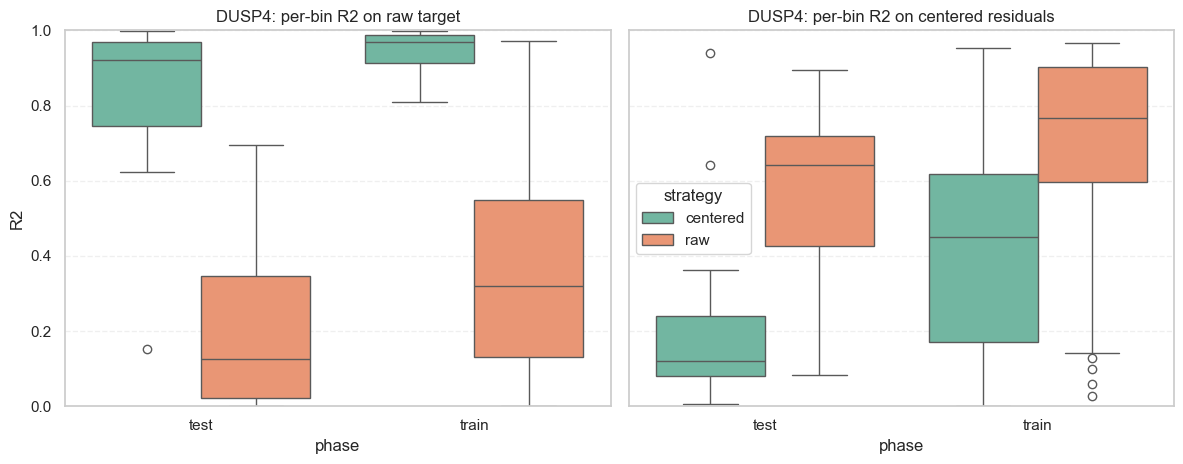

In [14]:
if pred_compare.empty:
    print("No predictions to compare.")
else:
    def safe_r2(y_true, y_pred):
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        if mask.sum() < 2:
            return np.nan
        yt = y_true[mask]
        yp = y_pred[mask]
        if len(np.unique(yp)) <= 1:
            return np.nan
        return float(np.corrcoef(yt, yp)[0, 1] ** 2)

    def compute_bin_r2(df, target_col, pred_col):
        records = []
        for (strategy, phase, b), group in df.groupby(["strategy", "phase", "GFP_bin"]):
            r2_val = safe_r2(group[target_col].to_numpy(), group[pred_col].to_numpy())
            records.append({"strategy": strategy, "phase": phase, "GFP_bin": b, "r2": r2_val})
        return pd.DataFrame(records).dropna(subset=["r2"])

    bin_r2_raw = compute_bin_r2(pred_compare, "target_raw", "pred_raw")
    bin_r2_centered = compute_bin_r2(pred_compare, "target_centered", "pred_centered")

    print("Per-bin R2 on raw target (center uses train-only means):")
    display(bin_r2_raw.head())
    print("Per-bin R2 on centered residuals (what the residual plots show):")
    display(bin_r2_centered.head())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
    sns.boxplot(data=bin_r2_raw, x="phase", y="r2", hue="strategy", palette="Set2", ax=axes[0])
    axes[0].set_ylim(0, 1)
    axes[0].set_title(f"{MARKER}: per-bin R2 on raw target")
    axes[0].set_ylabel("R2")
    axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

    sns.boxplot(data=bin_r2_centered, x="phase", y="r2", hue="strategy", palette="Set2", ax=axes[1])
    axes[1].set_ylim(0, 1)
    axes[1].set_title(f"{MARKER}: per-bin R2 on centered residuals")
    axes[1].set_ylabel("R2")
    axes[1].grid(True, axis="y", linestyle="--", alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend().remove()
    handles2, labels2 = axes[1].get_legend_handles_labels()
    if handles2:
        axes[1].legend(handles2, labels2, title="strategy")

    plt.tight_layout()
    plt.show()


Per-bin MAE on raw target:


,strategy,phase,GFP_bin,abs_error_raw
0,centered,test,0,0.083505
1,centered,test,4,0.134386
2,centered,test,6,0.076538
3,centered,test,10,0.099051
4,centered,test,12,0.067455


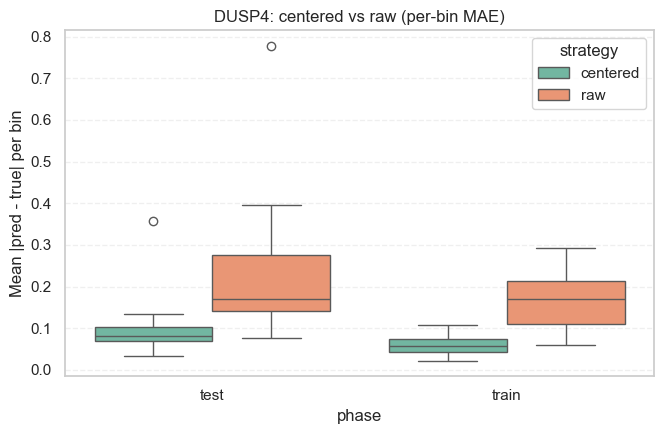

In [15]:
if pred_compare.empty:
    print("No predictions to compare.")
else:
    bin_mae = (
        pred_compare.groupby(["strategy", "phase", "GFP_bin"])["abs_error_raw"]
        .mean()
        .reset_index()
    )
    print("Per-bin MAE on raw target:")
    display(bin_mae.head())

    plt.figure(figsize=(6.8, 4.5))
    sns.boxplot(data=bin_mae, x="phase", y="abs_error_raw", hue="strategy", palette="Set2")
    plt.ylabel("Mean |pred - true| per bin")
    plt.title(f"{MARKER}: centered vs raw (per-bin MAE)")
    plt.grid(True, axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


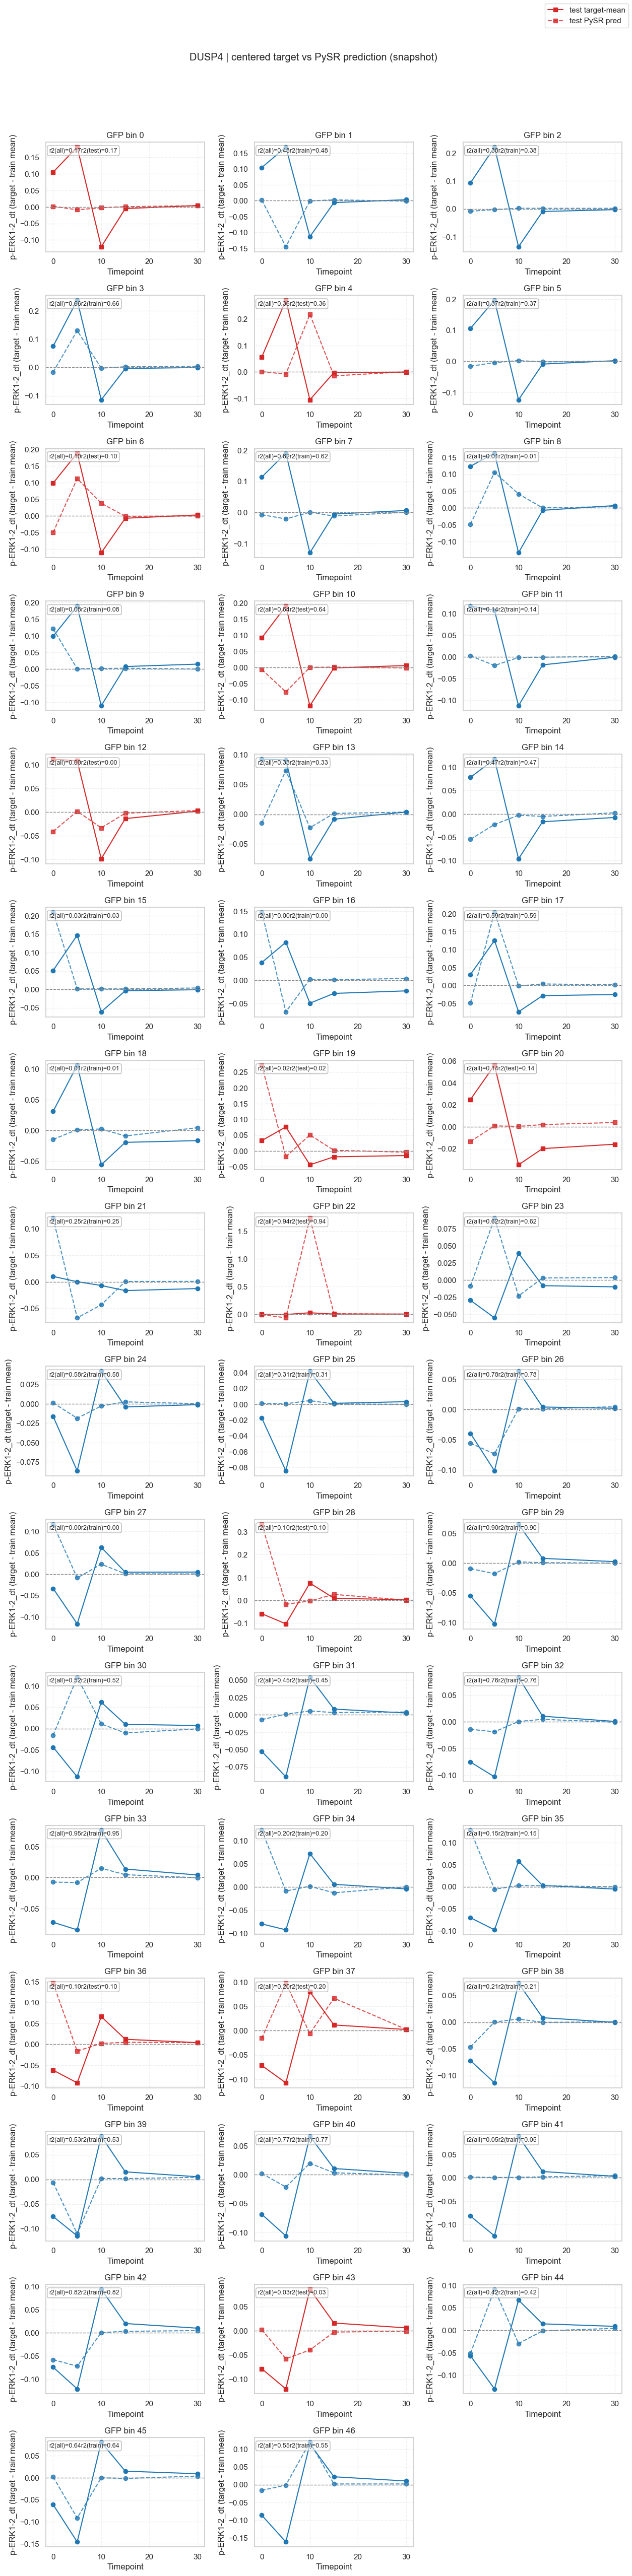

In [16]:
if plot_df_centered.empty:
    print("No data available to plot.")
else:
    bins = sorted(plot_df_centered["GFP_bin"].dropna().unique())
    ncols = 3
    nrows = math.ceil(len(bins) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), squeeze=False)

    phase_styles = {
        "train": {"color": "#1f77b4", "marker": "o"},
        "test": {"color": "#d62728", "marker": "s"},
    }

    def safe_r2(y_true, y_pred):
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        if mask.sum() < 2:
            return np.nan
        yt = y_true[mask]
        yp = y_pred[mask]
        if len(np.unique(yp)) <= 1:
            return np.nan
        return float(np.corrcoef(yt, yp)[0, 1] ** 2)

    for ax, b in zip(axes.flat, bins):
        sub = plot_df_centered[plot_df_centered["GFP_bin"] == b].copy().sort_values("timepoint")
        for phase, style in phase_styles.items():
            chunk = sub[sub["phase"] == phase]
            if chunk.empty:
                continue
            ax.plot(
                chunk["timepoint"],
                chunk["target_centered"],
                label=f"{phase} target-mean",
                marker=style["marker"],
                color=style["color"],
                linestyle="-",
            )
            ax.plot(
                chunk["timepoint"],
                chunk["pred_centered"],
                label=f"{phase} PySR pred",
                marker=style["marker"],
                color=style["color"],
                linestyle="--",
                alpha=0.8,
            )
        r2_all = safe_r2(sub["target_centered"].to_numpy(), sub["pred_centered"].to_numpy())
        r2_train = safe_r2(sub[sub["phase"] == "train"]["target_centered"].to_numpy(), sub[sub["phase"] == "train"]["pred_centered"].to_numpy())
        r2_test = safe_r2(sub[sub["phase"] == "test"]["target_centered"].to_numpy(), sub[sub["phase"] == "test"]["pred_centered"].to_numpy())

        txt_lines = [f"r2(all)={r2_all:.2f}" if not np.isnan(r2_all) else "r2(all)=nan"]
        if not np.isnan(r2_train):
            txt_lines.append(f"r2(train)={r2_train:.2f}")
        if not np.isnan(r2_test):
            txt_lines.append(f"r2(test)={r2_test:.2f}")
        ax.text(
            0.02,
            0.95,
        "".join(txt_lines),
            transform=ax.transAxes,
            verticalalignment="top",
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.6, edgecolor="#888"),
        )

        ax.axhline(0, color="#888", linestyle="--", linewidth=1)
        ax.set_title(f"GFP bin {int(b) if float(b).is_integer() else b}")
        ax.set_xlabel("Timepoint")
        ax.set_ylabel("p-ERK1-2_dt (target - train mean)")
        ax.grid(True, linestyle="--", alpha=0.3)

    for ax in axes.flat[len(bins) :]:
        ax.axis("off")

    handles = []
    labels = []
    for a in axes.flat:
        h, l = a.get_legend_handles_labels()
        if h:
            handles, labels = h, l
            break

    if handles:
        fig.legend(handles, labels, loc="upper right", frameon=True)
    fig.suptitle(f"{MARKER} | centered target vs PySR prediction (snapshot)")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()
